### Introduction

This notebook focuses on building the forecasting model by following the workflow presented in the skforecast documentation example [Forecasting energy demand with machine learning by Joaquín Amat Rodrigo and Javier Escobar Ortiz](https://cienciadedatos.net/documentos/py29-forecasting-electricity-power-demand-python.html).

In [ ]:
import pandas as pd

# storage
from src.data.storage import S3Bucket, S3DatasetStore
from src.data.storage.partition_filters import dates_between
from src.data.storage.stores.forecaster import write_forecaster

# plotting
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme

# features
from sklearn.pipeline import Pipeline
from feature_engine.datetime import DatetimeFeatures
from skforecast.preprocessing import RollingFeatures
from feature_engine.timeseries.forecasting import WindowFeatures
from src.features.transformers import WeightedAverage

# split
from src.model.split import Interval, split

# modelling
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster, bayesian_search_forecaster
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from lightgbm import LGBMRegressor

### Data

Electricity consumption and temperature data for 2023–2025 is loaded from S3. For information on data sources and storage structure, see the previous notebook.

In [2]:
# date range
start_date="2023-01-01"
end_date="2025-12-31"

# S3 configs
bucket = S3Bucket("ts-forecast-boramkesil")
dataset = S3DatasetStore(
    prefix="tr_consumption_temperature_hourly",
    partition_columns=["date"]
)

# partition filter 
filter = dates_between(
    partition_column="date",
    start_date=start_date,
    end_date=end_date,
)

In [3]:
# retrieve data from S3
data = dataset.read_partitioned(s3_bucket=bucket, partition_filter=filter)
data

,consumption,istanbul_temp,ankara_temp,izmir_temp,antalya_temp,bursa_temp
datetime,,,,,,
2023-01-01 00:00:00,28836.10,4.5,-1.6,8.3,7.2,7.1
2023-01-01 01:00:00,27608.62,5.0,-0.7,8.1,7.0,6.3
2023-01-01 02:00:00,26347.75,5.2,0.8,7.7,6.9,6.1
2023-01-01 03:00:00,25243.18,5.4,-1.9,7.3,6.7,4.5
2023-01-01 04:00:00,24654.99,6.2,-2.2,6.6,6.4,4.5
...,...,...,...,...,...,...
2025-12-31 19:00:00,42962.65,0.3,-2.0,4.5,9.7,-0.6
2025-12-31 20:00:00,40748.00,0.0,-3.0,3.6,8.8,-1.9
2025-12-31 21:00:00,38865.29,0.1,-2.1,3.2,8.9,-3.3


The documentation recommends verifying that the time series is intact. This check is performed before proceeding with modeling.

In [125]:
# expected continuous hourly timeline
# between first and last timestamp
expected_date_range = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="h"
)

# check for missing/extra timestamps in the index
dates_complete = data.index.equals(expected_date_range)

# set hourly frequency
dataset = data.asfreq("h")

# count rows with any missing feature/target values
missing_row_count = data.isnull().any(axis=1).sum()

print(f"Dates complete: {dates_complete}")
print(f"Rows with missing values: {missing_row_count}")

Dates complete: True
Rows with missing values: 0


### Train/Validation/Test

The dataset is split into training, validation, and test intervals using the `Interval` class and `split(...)` function implemented for this project. In this case, the test interval covers the last month of 2025, the validation interval covers approximately the 11 months preceding the test period, and the training interval includes all remaining data before the validation period. These intervals are used to slice the dataset for hyperparameter tuning and model evaluation.

In [126]:
train, validation, test = split(data, validation_days=11*30, test_days=31)

print(f"Train dates      : {train}")
print(f"Validation dates : {validation}")
print(f"Test dates       : {test}")

Train dates      : Interval(start=2023-01-01 00:00:00, end=2025-01-04 23:00:00, length=17640)
Validation dates : Interval(start=2025-01-05 00:00:00, end=2025-11-30 23:00:00, length=7920)
Test dates       : Interval(start=2025-12-01 00:00:00, end=2025-12-31 23:00:00, length=744)


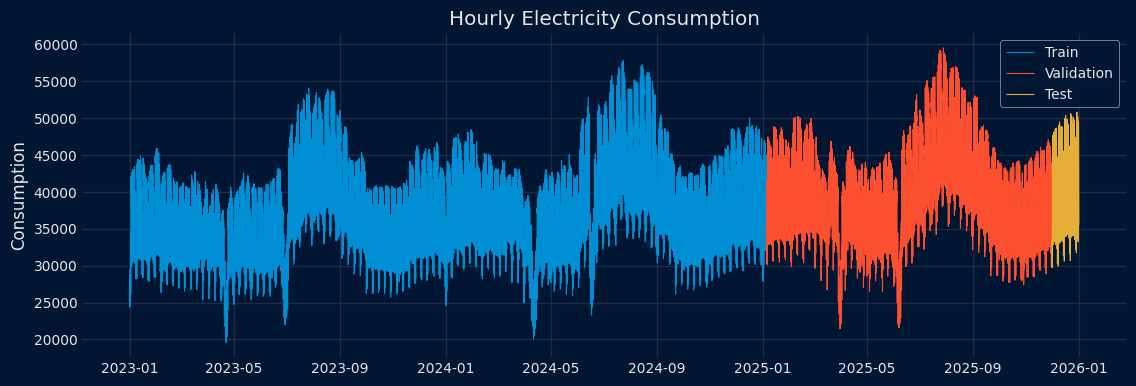

In [127]:
set_dark_theme()
plt.figure(figsize=(12, 4))

# plot target series across time-based splits
plt.plot(train.slice(data).index, train.slice(data)["consumption"], label="Train", linewidth=0.8)
plt.plot(validation.slice(data).index, validation.slice(data)["consumption"], label="Validation", linewidth=0.8)
plt.plot(test.slice(data).index, test.slice(data)["consumption"], label="Test", linewidth=0.8)

plt.title("Hourly Electricity Consumption")
plt.ylabel("Consumption")
plt.legend()
plt.show()

Seasonal plots can be used to highlight repeating patterns over hours, days, or months.

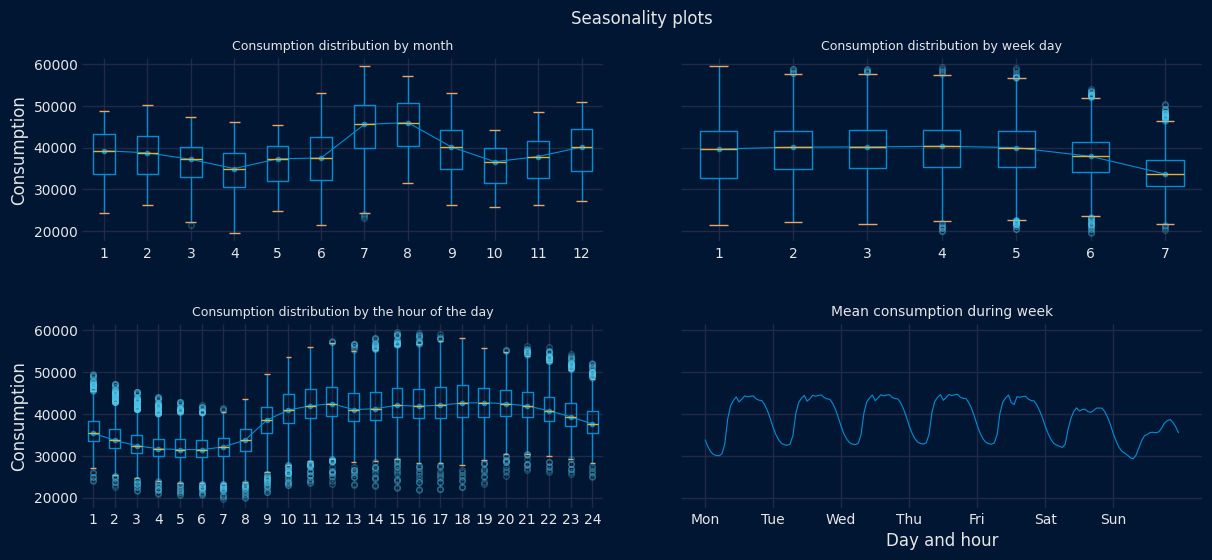

In [128]:
# annual, weekly and daily seasonality
d = data.copy()

d["month"]    = d.index.month
d["week_day"] = d.index.day_of_week + 1     # 1=Mon ... 7=Sun
d["hour_day"] = d.index.hour + 1            # 1..24

fig, axs = plt.subplots(2, 2, figsize=(14, 6), sharex=False, sharey=True)
axs = axs.ravel()

def boxplot_with_median(df, by, ax, title):
    """Boxplot + median line for consumption grouped by `by`."""
    df.boxplot(
        column="consumption",
        by=by,
        ax=ax,
        capprops={"color": "#F4A261"},
        flierprops={"markersize": 4, "alpha": 0.3, "markeredgecolor": "#4CC9F0"},
        grid=False,
    )
    df.groupby(by)["consumption"].median().plot(
        style="o-",
        linewidth=0.8,
        markersize=3,
        ax=ax,
    )
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("Consumption")
    ax.set_xlabel("")  # remove pandas' default 'by' xlabel

boxplot_with_median(d, "month", axs[0], "Consumption distribution by month")
boxplot_with_median(d, "week_day", axs[1], "Consumption distribution by week day")
boxplot_with_median(d, "hour_day", axs[2], "Consumption distribution by the hour of the day")

# mean consumption by (week_day, hour_day)
mean_day_hour = d.groupby(["week_day", "hour_day"])["consumption"].mean().sort_index()
mean_day_hour.plot(ax=axs[3], linewidth=0.8)
axs[3].set(
    title="Mean consumption during week",
    xticks=[i * 24 for i in range(7)],
    xticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel="Day and hour",
    ylabel="Mean consumption",
)
axs[3].title.set_size(10)

fig.suptitle("Seasonality plots", fontsize=12)
fig.subplots_adjust(wspace=0.15, hspace=0.45)
plt.show()

### Forecaster

The documentation recommends starting with a baseline model when approaching a forecasting task. A baseline forecaster is fit in the next cells and evaluated via [backtesting](https://skforecast.org/0.19.1/user_guides/backtesting). Backtesting consists of training the model on a portion of the series and evaluating its forecasts on unseen observations. The error obtained here is used as a benchmark when comparing against more complex models later in the notebook.

In [129]:
X = data.drop(columns=["consumption"])
y = data["consumption"].asfreq("h")

In [130]:
# create baseline: value of the same 
# hour of the previous day
forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(days=1),
                 n_offsets = 1
             )

# train
forecaster.fit(y=(train + validation).slice(y))
forecaster

======================== 
ForecasterEquivalentDate 
======================== 
Offset: <DateOffset: days=1> 
Number of offsets: 1 
Aggregation function: mean 
Window size: 24 
Series name: consumption 
Training range: [Timestamp('2023-01-01 00:00:00'), Timestamp('2025-11-30 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-03-02 22:18:27 
Last fit date: 2026-03-02 22:18:27 
Skforecast version: 0.20.1 
Python version: 3.11.5 
Forecaster id: None

In [131]:
# backtesting
cv = TimeSeriesFold(
        steps              = 24,
        initial_train_size = (train + validation).length,
        refit              = False
)
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = y,
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                       )
metric

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 495.71it/s]


,mean_absolute_error
0,2228.955591


### Recursive Multi-Step Forecasting

Following the approach described in the documentation, a recursive autoregressive forecaster with a gradient boosting estimator (`LGBMRegressor`) is trained to predict electricity consumption for the next 24 hours. The model uses the previous 24 hourly consumption values (24 lags) as predictors, along with a 3-day moving average feature.

In [132]:
# create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

# train
forecaster.fit(y=(train + validation).slice(y))
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: ['roll_mean_72'] 
Window size: 72 
Series name: consumption 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2023-01-01 00:00:00'), Timestamp('2025-11-30 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 15926, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample':
    1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-03-02 22:18:29 
Last fit date: 2026-03-02 22:18:29 
Skforecast version: 0.20.1 
Python version: 3.11.5 
Forecaster id: None

In [133]:
# backtesting
metric, predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = y,
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 313.98it/s]


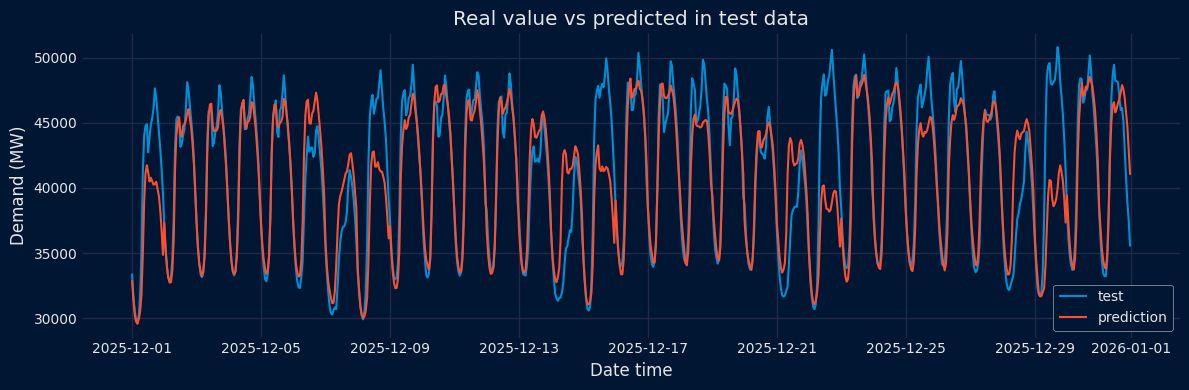

In [134]:
plt.figure(figsize=(12, 4))
plt.plot(test.slice(y).index, test.slice(y), label="test")
plt.plot(predictions.index, predictions["pred"], label="prediction")
plt.title("Real value vs predicted in test data")
plt.xlabel("Date time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

In [135]:
metric

,mean_absolute_error
0,1864.240026


The autoregressive model outperforms the baseline model, achieving a lower MAE.

### Exogenouse Variables

Exogenous features are created to provide the model with additional information beyond past electricity consumption. Temperature data from multiple provinces is combined into a single weighted temperature variable. If all five temperature series are used directly, the number of features can grow quickly once window-based statistics (such as rolling means or lags) are added. To avoid this, a `WeightedAverage` transformer is implemented to combine the province-level temperature columns into a single weighted temperature feature using a weighted arithmetic mean. From this aggregated temperature variable, 24-hour and 168-hour rolling statistics (mean, maximum, and minimum) are calculated to capture short-term and weekly temperature patterns. Calendar features such as month, week, hour, and day of week are also extracted from the datetime index to reflect seasonal and daily patterns. These features help the model better capture how weather and time-related factors influence electricity demand.

In [136]:
# Combine province temperatures into a single weighted temperature
weighted_average_transformer = WeightedAverage(
    weight_map={
        "istanbul_temp": 22.28,
        "ankara_temp":   7.19,
        "izmir_temp":    7.06,
        "antalya_temp":  5.45,
        "bursa_temp":    4.38,
    },
    output_name="temp_weighted",
    drop_original=True
)

# Create rolling window features (24h & 168h) from weighted temperature
window_features_transformer = WindowFeatures(
    variables   = ["temp_weighted"],
    window      = [24, 168],
    functions   = ["mean", "max", "min"],
)

# Extract calendar features from datetime index
features_to_extract = ['month', 'week', 'hour', 'day_of_week']
calendar_features_transformer = DatetimeFeatures(
    variables           = 'index',
    features_to_extract = features_to_extract,
    drop_original       = True,
)

# Combine all exogenous feature transformations into a pipeline
transformer_exog = Pipeline([
    ("dt_features", calendar_features_transformer),
    ("reduce_dim", weighted_average_transformer),
    ("window_features", window_features_transformer),
])

In [137]:
# fit_transform pipeline
data_transformed = transformer_exog.fit_transform(data)
data_transformed

,consumption,month,week,hour,day_of_week,temp_weighted,temp_weighted_window_24_mean,temp_weighted_window_24_max,temp_weighted_window_24_min,temp_weighted_window_168_mean,temp_weighted_window_168_max,temp_weighted_window_168_min
datetime,,,,,,,,,,,,
2023-01-01 00:00:00,28836.10,1,52,0,6,4.695686,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01 01:00:00,27608.62,1,52,1,6,4.946009,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01 02:00:00,26347.75,1,52,2,6,5.183197,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01 03:00:00,25243.18,1,52,3,6,4.624978,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01 04:00:00,24654.99,1,52,4,6,4.821053,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,42962.65,12,1,19,2,1.602912,4.870241,8.370298,2.383822,6.024953,12.588611,0.879336
2025-12-31 20:00:00,40748.00,12,1,20,2,0.937964,4.588267,7.511324,1.602912,5.973748,12.588611,0.879336
2025-12-31 21:00:00,38865.29,12,1,21,2,0.944176,4.314377,7.139970,0.937964,5.921109,12.588611,0.879336


The transformed dataframe includes the calendar features and the weighted temperature with rolling window features. These rolling features introduce NaN values at the beginning of the dataset, which needs to be dropped before modeling. After that forecaster is backtested with exogenous variables.

In [138]:
data_transformed = data_transformed.iloc[7 * 24:, :]

train, validation, test = split(data_transformed, validation_days=11*30, test_days=31)

X = data_transformed.drop(columns=["consumption"])
y = data_transformed["consumption"].asfreq("h")

In [139]:
# backtesting
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = y,
                          exog       = X,
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )

metric

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 266.72it/s]


,mean_absolute_error
0,807.722229


The inclusion of exogenous variables as predictors improves the predictive capacity of the model.

### Hyperparameter Tunning

The `ForecasterRecursive` is initially trained using 24 lags and an `LGBMRegressor` with default hyperparameters. These values are not necessarily optimal, so a [Bayesian search](https://skforecast.org/0.20.1/user_guides/hyperparameter-tuning-and-lags-selection.html#bayesian-search) is performed with `bayesian_search_forecaster` to find the best combination of lags and hyperparameters. The search uses the same backtesting procedure as before, but each iteration trains the model with different hyperparameter configurations.

In [140]:
# hyperparameters search
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

# lags used as predictors
lags_grid = [24, (1, 2, 3, 23, 24, 25, 47, 48, 49)]

# estimator hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 300, 1000, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    } 
    return search_space

# folds training and validation
cv_search = TimeSeriesFold(
                steps              = 24,
                initial_train_size = train.length,
                refit              = False,
            )

results_search, frozen_trial = bayesian_search_forecaster(
                                   forecaster   = forecaster,
                                   y            = (train + validation).slice(y),
                                   exog         = (train + validation).slice(X),
                                   cv           = cv_search,
                                   metric       = 'mean_absolute_error',
                                   search_space = search_space,
                                   n_trials     = 10,
                                   return_best  = True
                               )

Best trial: 0. Best value: 862.956: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:20<00:00,  2.02s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 23 24 25 47 48 49] 
  Parameters: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.12115721224645952, 'reg_alpha': 0.5513147690828912, 'reg_lambda': 0.7194689697855631}
  Backtesting metric: 862.9564025616029


In [141]:
best_params = results_search.at[0, 'params']
best_params = best_params | {'random_state': 15926, 'verbose': -1}
best_lags   = results_search.at[0, 'lags']
results_search.head(3)

,lags,params,mean_absolute_error,n_estimators,max_depth,learning_rate,reg_alpha,reg_lambda
0,"[1, 2, 3, 23, 24, 25, 47, 48, 49]","{'n_estimators': 800, 'max_depth': 5, 'learnin...",862.956403,800.0,5.0,0.121157,0.551315,0.719469
1,"[1, 2, 3, 23, 24, 25, 47, 48, 49]","{'n_estimators': 600, 'max_depth': 8, 'learnin...",886.695962,600.0,8.0,0.099421,0.175452,0.531551
2,"[1, 2, 3, 23, 24, 25, 47, 48, 49]","{'n_estimators': 800, 'max_depth': 9, 'learnin...",916.308900,800.0,9.0,0.050766,0.763683,0.243666


Since `return_best=True`, the forecaster is automatically updated with the best hyperparameter configuration found during the search and retrained on the entire dataset.

In [162]:
# backtest final model on test data
cv = TimeSeriesFold(
        steps              = 24,
        initial_train_size = (train + validation).length,
        refit              = False
)

metric, predictions = backtesting_forecaster(
                            forecaster              = forecaster,
                            y                       = y,
                            exog                    = X,
                            cv                      = cv,
                            metric                  = 'mean_absolute_error',
                       )
display(metric)
predictions

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 208.80it/s]


,mean_absolute_error
0,649.21907


,fold,pred
2025-12-01 00:00:00,0,33264.757898
2025-12-01 01:00:00,0,31792.908913
2025-12-01 02:00:00,0,30471.397883
2025-12-01 03:00:00,0,29851.811082
2025-12-01 04:00:00,0,29893.850676
...,...,...
2025-12-31 19:00:00,30,47126.354382
2025-12-31 20:00:00,30,45726.317965
2025-12-31 21:00:00,30,44053.962719
2025-12-31 22:00:00,30,42193.874772


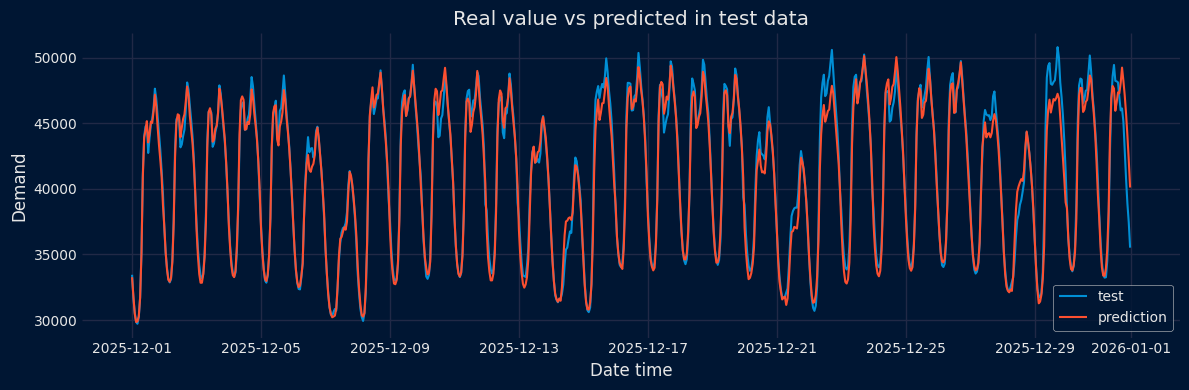

In [163]:
plt.figure(figsize=(12, 4))
plt.plot(test.slice(y).index, test.slice(y), label="test")
plt.plot(predictions.index, predictions["pred"], label="prediction")
plt.title("Real value vs predicted in test data")
plt.xlabel("Date time")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

After optimization of lags and hyperparameters, the prediction error was reduced. Finally we can save the forecaster in s3.

In [171]:
# write forecaster to target s3 bucket
forecaster.forecaster_id = "lgbm_recursive_v1"
write_forecaster(forecaster, bucket)

![S3 forecaster](images/forecaster_store.png)